In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import galsim
import batsim
import numpy as np
import matplotlib.pyplot as plt
from parallelbar import progress_starmap

from tqdm import tqdm
from time import time

from importlib import reload
reload(batsim)

np.random.seed(14)

In [2]:
n_gals = 1000
scale = 0.2
nn = 64

cosmos = galsim.COSMOSCatalog()
inds = np.random.choice(len(cosmos), n_gals, replace=False)
gal_list = [cosmos.makeGalaxy(index=i, gal_type='parametric') for i in inds]

psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# Extract parameters for each galaxy
hlrs = np.zeros(n_gals)
sersic_inds = np.zeros(n_gals)
for i, j in enumerate(inds):
    rec = cosmos.getParametricRecord(j)
    if bool(rec['use_bulgefit']):
        hlrs[i] = rec['hlr'][2]
        sersic_inds[i] = 0
    else:
        hlrs[i] = rec['hlr'][0]
        sersic_inds[i] = rec['sersicfit'][2]

In [3]:
lens_shear = 0.02

args_list = [(gal, psf, scale, nn, lens_shear) for gal in gal_list]

def parse_batsim_args(gal, psf, scale, nn, lens_shear):

    LensTransform = batsim.LensTransform(gamma1=lens_shear, gamma2=0, kappa=0)

    bat_im = batsim.simulate_galaxy(
        gal_obj=gal, 
        psf_obj=psf,
        transform_obj=LensTransform,
        scale=scale,
        ngrid=nn,
        backend='numpy',
        integration_order=2
    )
    return bat_im

batsim_images = progress_starmap(
    parse_batsim_args, 
    args_list, 
    n_cpu=48
)

DONE:   0%|          | 0/1000 [00:00<?, ?it/s]

In [6]:
def parse_galsim_args(gal, psf, scale, nn, lens_shear):
    gal_conv = galsim.Convolve([gal, psf])
    gal_conv = gal_conv.shear(g1=lens_shear)
    gal_im = gal_conv.drawImage(scale=scale, nx=nn, ny=nn, use_true_center=True)
    return gal_im.array

galsim_images = progress_starmap(
    parse_galsim_args, 
    args_list, 
    n_cpu=48
)

DONE:   0%|          | 0/1000 [00:00<?, ?it/s]

Fraction of galaxies with <1% residuals: 0.4890


<Figure size 640x480 with 0 Axes>

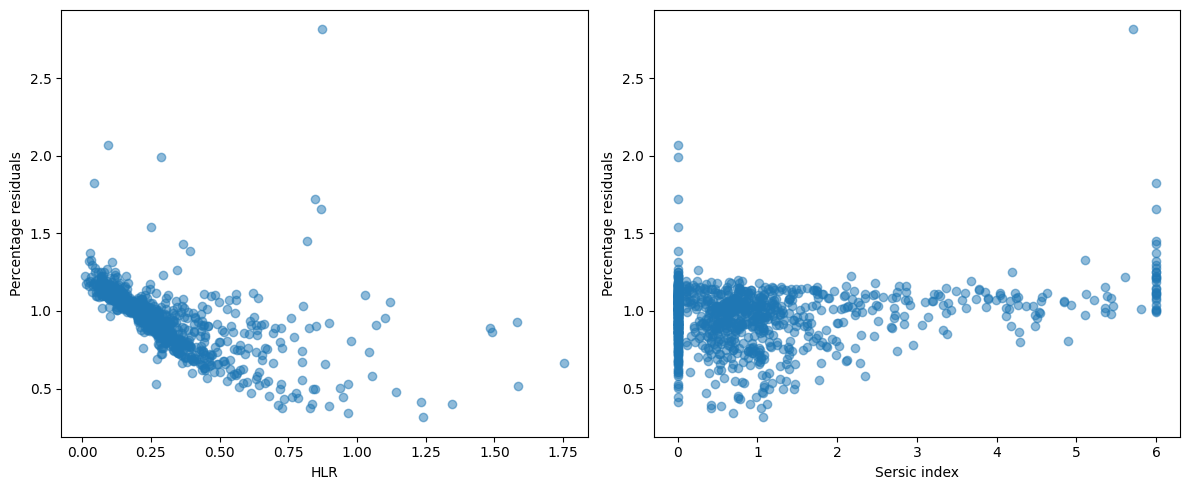

In [7]:
residuals = np.zeros(len(galsim_images))
perc_residuals = np.zeros(len(galsim_images))
for i in range(len(galsim_images)):
    residuals[i] = abs(galsim_images[i] - batsim_images[i]).max()
    perc_residuals[i] = 100 * residuals[i] / galsim_images[i].max()

# estimate fraction with sub-% residuals
frac_sub_1perc = np.mean(perc_residuals < 1)
print(f'Fraction of galaxies with <1% residuals: {frac_sub_1perc:.4f}')

plt.figure()
plt.subplots(1, 2, figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(hlrs, perc_residuals, alpha=0.5)
plt.xlabel('HLR')
plt.ylabel('Percentage residuals')
plt.subplot(1, 2, 2)
plt.scatter(sersic_inds, perc_residuals, alpha=0.5)
plt.xlabel('Sersic index')
plt.ylabel('Percentage residuals')
plt.tight_layout()
plt.show()